In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
df=pd.read_csv('/content/drive/MyDrive/ML_Projects/AIML Dataset.csv')

In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [9]:
df['isFraud'].value_counts()

,count
isFraud,
0,6354407
1,8213


EDA using transaction type


In [10]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


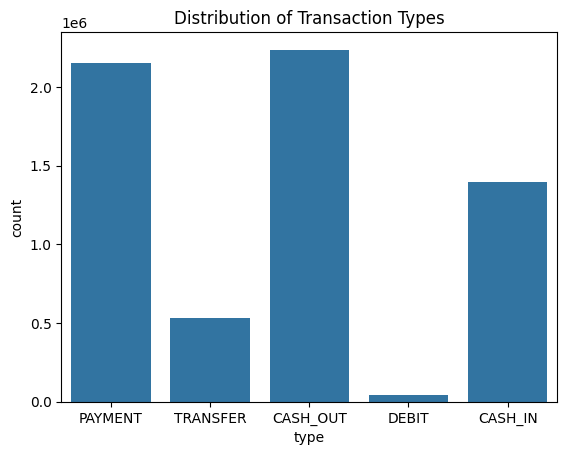

In [11]:
sns.countplot(x='type', data=df)
plt.title('Distribution of Transaction Types')
plt.show()

In [12]:
df['isFraud'].value_counts()

,count
isFraud,
0,6354407
1,8213


<Axes: xlabel='isFraud', ylabel='count'>

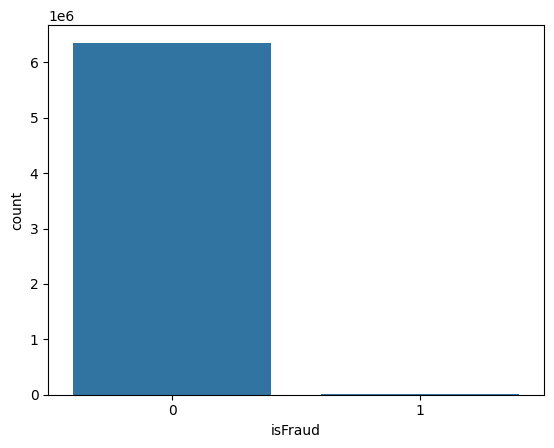

In [13]:
sns.countplot(x='isFraud', data=df)

<Axes: xlabel='type', ylabel='count'>

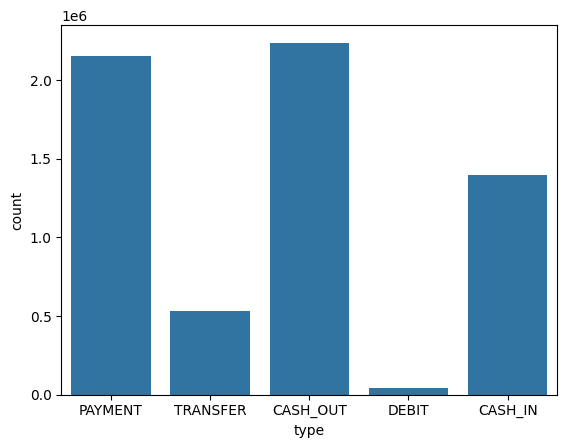

In [14]:
sns.countplot(x='type', data=df)


<Axes: xlabel='type', ylabel='count'>

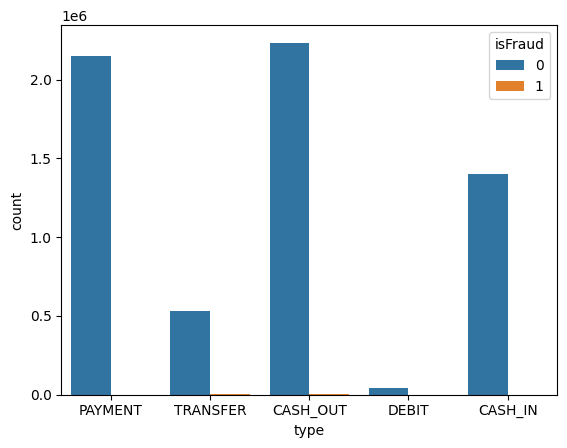

In [15]:
sns.countplot(x='type', hue='isFraud', data=df)

<Axes: xlabel='amount', ylabel='Count'>

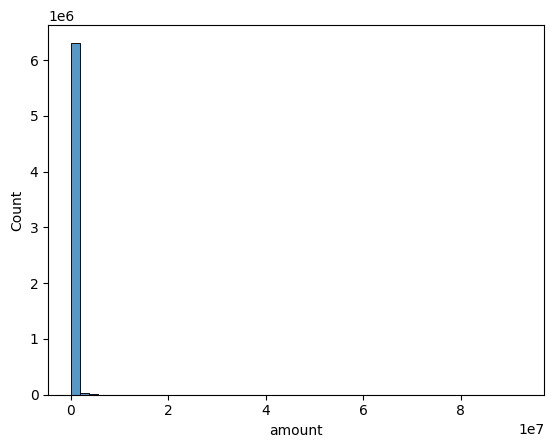

In [16]:
sns.histplot(df['amount'], bins=50)

<Axes: xlabel='isFraud', ylabel='amount'>

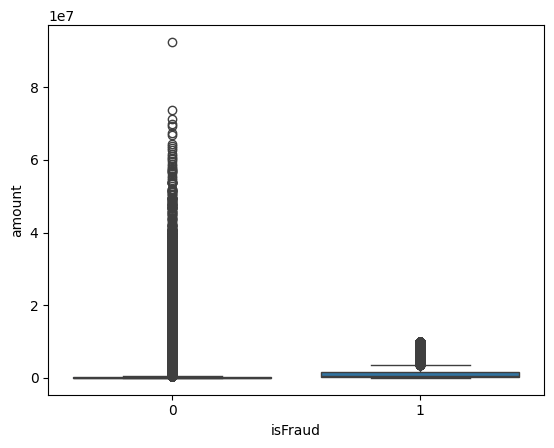

In [17]:
sns.boxplot(x='isFraud', y='amount', data=df)

/tmp/ipykernel_6268/935290909.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_rate = df.groupby('amount_bin')['isFraud'].mean()


Text(0, 0.5, 'Fraud Rate (%)')

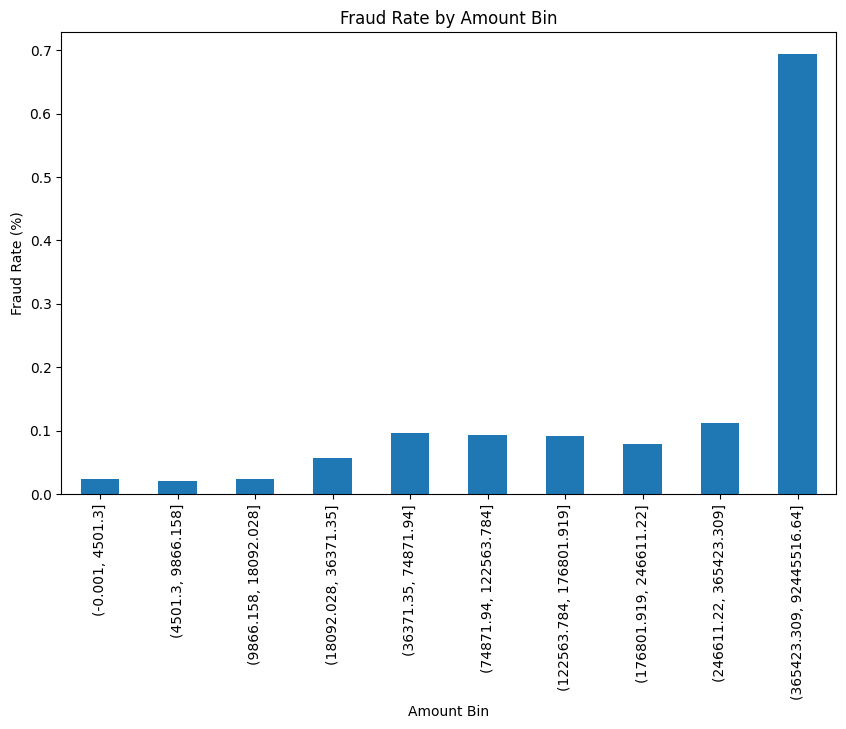

In [18]:
df['amount_bin'] = pd.qcut(df['amount'], q=10, duplicates='drop')
fraud_rate = df.groupby('amount_bin')['isFraud'].mean()
fraud_rate = fraud_rate * 100

plt.figure(figsize=(10, 6))
fraud_rate.plot(kind='bar')
plt.title('Fraud Rate by Amount Bin')
plt.xlabel('Amount Bin')
plt.ylabel('Fraud Rate (%)')

In [19]:
merchant_txns=df[df['nameDest'].str.startswith('M')]
merchant_txns[['oldbalanceDest','newbalanceDest']].describe()

,oldbalanceDest,newbalanceDest
count,2151495.0,2151495.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,0.0,0.0


<Axes: xlabel='isFraud', ylabel='amount'>

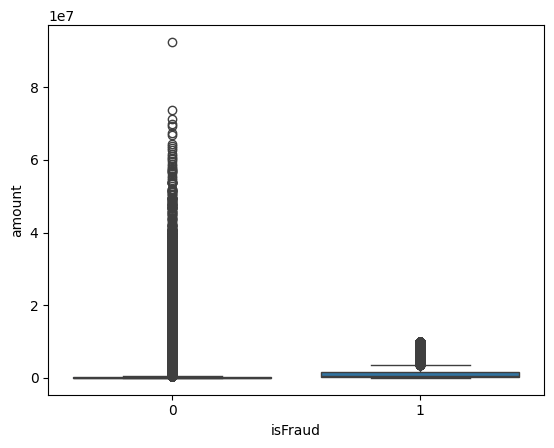

In [20]:
sns.boxplot(x='isFraud', y='amount', data=df)

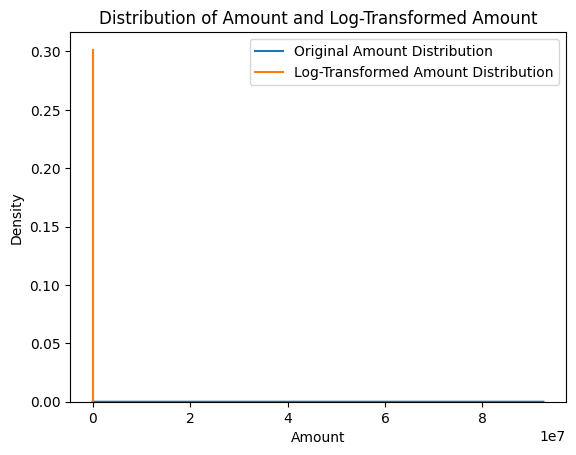

In [21]:
sns.kdeplot(df['amount'], label='Original Amount Distribution')
sns.kdeplot(np.log1p(df['amount']), label='Log-Transformed Amount Distribution')
plt.title('Distribution of Amount and Log-Transformed Amount')
plt.xlabel('Amount')
plt.ylabel('Density')
plt.legend()
plt.show()

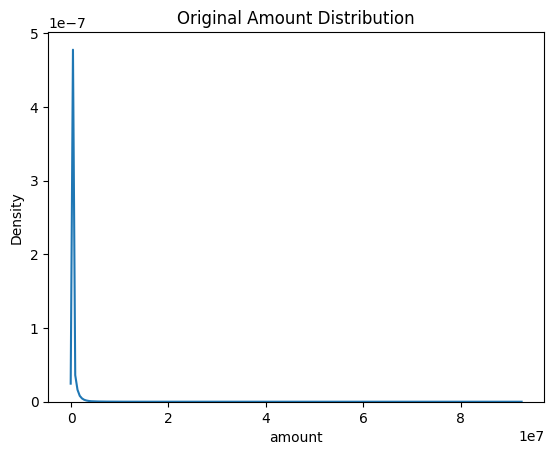

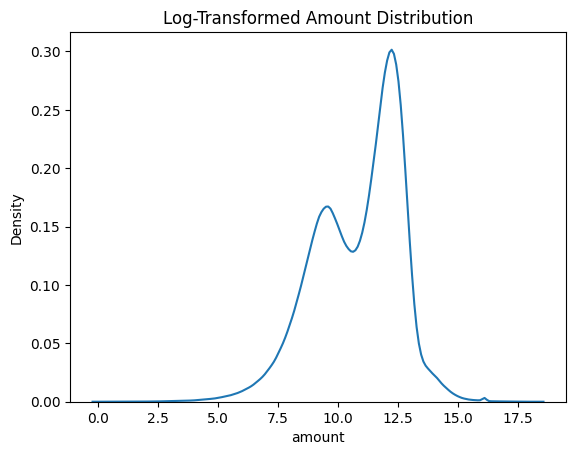

In [22]:
plt.figure()
sns.kdeplot(df['amount'])
plt.title("Original Amount Distribution")
plt.show()

plt.figure()
sns.kdeplot(np.log1p(df['amount']))
plt.title("Log-Transformed Amount Distribution")
plt.show()

In [23]:
df['log_amount']=np.log1p(df['amount'])

p99=df['log_amount'].quantile(0.99)
df['is_high_amount']=(df['log_amount']>p99).astype(int)
df['is_high_amount'].value_counts()

,count
is_high_amount,
0,6298993
1,63627


<Axes: xlabel='isFraud', ylabel='log_amount'>

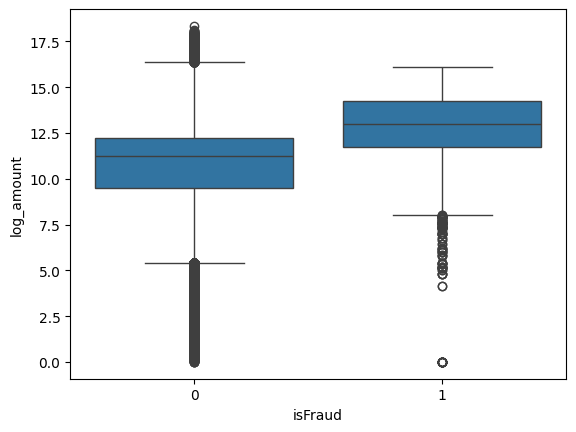

In [24]:
sns.boxplot(x='isFraud', y='log_amount', data=df)

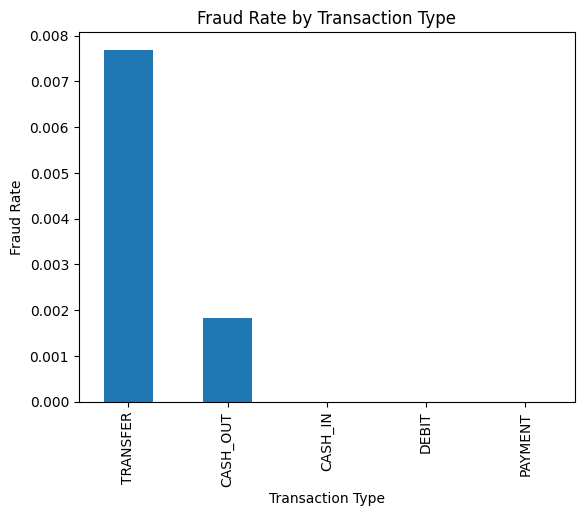

In [25]:
df.groupby('type')['isFraud'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Fraud Rate by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate')
plt.show()

In [26]:
df.sample(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,amount_bin,log_amount,is_high_amount
4186966,305,CASH_OUT,220972.16,C1565498980,0.00,0.00,C1097431872,1061910.26,1282882.43,0,0,"(176801.919, 246611.22]",12.305797,0
2889391,228,CASH_IN,236489.68,C127783278,5546.00,242035.68,C669009703,0.00,0.00,0,0,"(176801.919, 246611.22]",12.373664,0
3748514,279,PAYMENT,3885.68,C107176945,502.00,0.00,M849339939,0.00,0.00,0,0,"(-0.001, 4501.3]",8.265311,0
5277088,372,CASH_IN,92610.50,C1936239074,8518833.82,8611444.32,C1881297341,1681796.22,1589185.72,0,0,"(74871.94, 122563.784]",11.436169,0
1329860,137,PAYMENT,10362.05,C905891992,10812.00,449.95,M1016386590,0.00,0.00,0,0,"(9866.158, 18092.028]",9.246002,0


In [27]:
df['hour']=df['step'] % 24

hourly_stats = df.groupby('hour')['isFraud'].agg([
    ('total_transactions', 'count'),   # total transactions
    ('fraud_transactions', 'sum'),     # number of frauds
    ('fraud_rate', 'mean')             # fraud percentage
]).reset_index()

display(hourly_stats.head())

,hour,total_transactions,fraud_transactions,fraud_rate
0,0,71587,300,0.004191
1,1,27111,358,0.013205
2,2,9018,372,0.041251
3,3,2007,326,0.162431
4,4,1241,274,0.220790


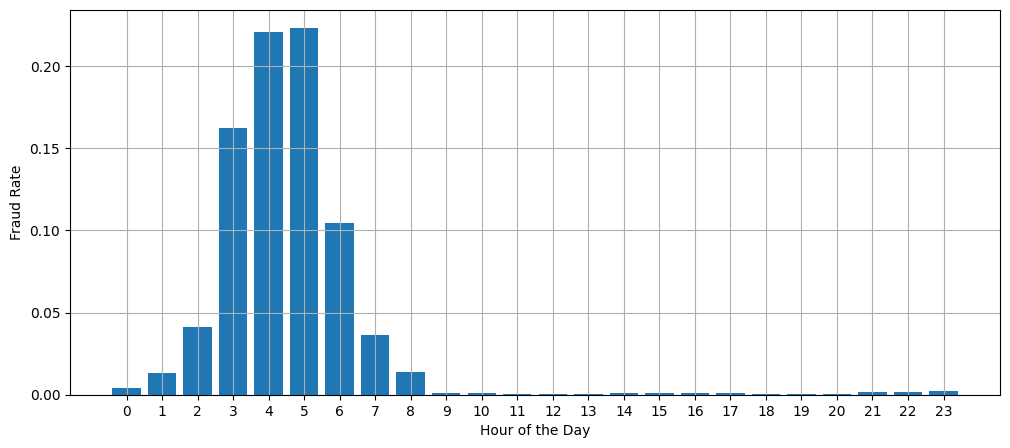

In [28]:
plt.figure(figsize=(12,5))
plt.bar(hourly_stats['hour'],hourly_stats['fraud_rate'])
plt.xticks(hourly_stats['hour'])
plt.xlabel('Hour of the Day')
plt.ylabel('Fraud Rate')
plt.grid()

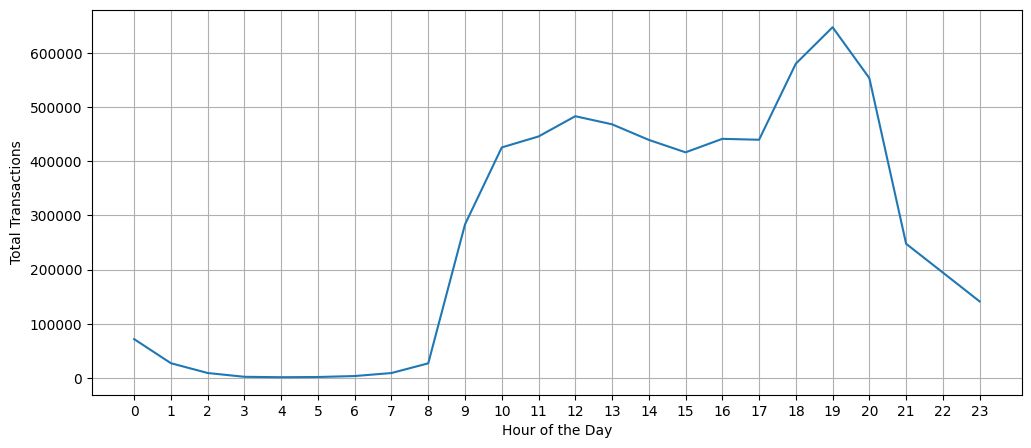

In [29]:
plt.figure(figsize=(12,5))
plt.plot(hourly_stats['hour'],hourly_stats['total_transactions'])
plt.xticks(hourly_stats['hour'])
plt.xlabel('Hour of the Day')
plt.ylabel('Total Transactions')
plt.xticks(range(0,24))
plt.grid()

Text(0.5, 1.0, 'Fraud Rate:Day vs Night')

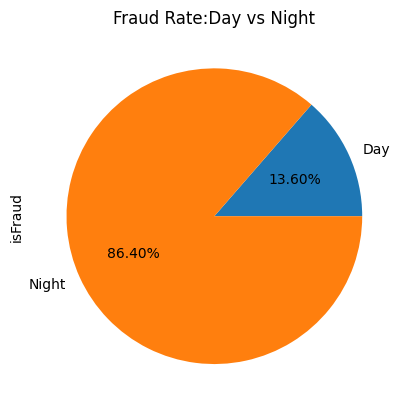

In [30]:
df['is_night']=df['hour'].isin([0,1,2,3,4,5,22,23]).astype(int)

day_night_fraud=(
    df.groupby('is_night')['isFraud']
    .mean()
    .rename({0:'Day',1:'Night'})
)
day_night_fraud.plot(kind='pie',autopct='%1.2f%%')

plt.title("Fraud Rate:Day vs Night")

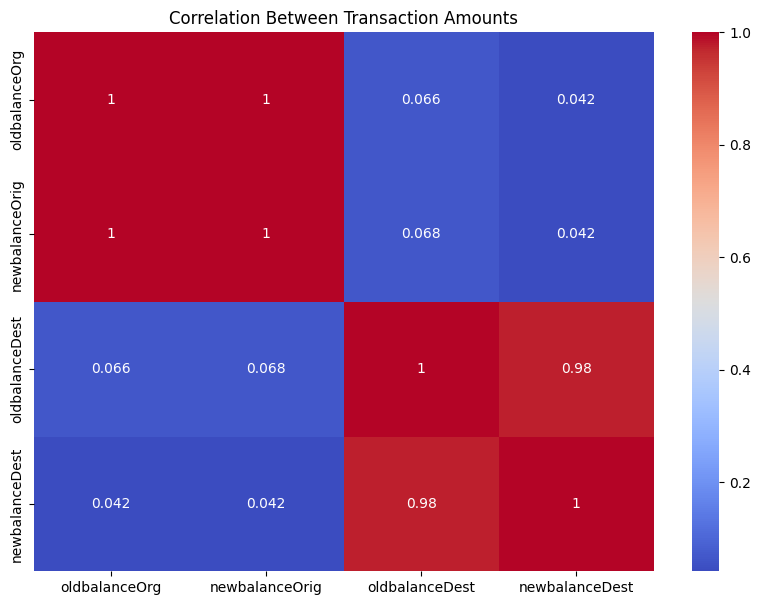

In [34]:
plt.figure(figsize=(10,7))
corr=df[['oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('Correlation Between Transaction Amounts')
plt.show()

In [37]:
df['balance_diff_orig']=df['oldbalanceOrg']-df['newbalanceOrig']
df['balance_diff_dest']=df['oldbalanceDest']-df['newbalanceDest']

df=df.drop(columns=['oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest'])

In [40]:
df.head()

,step,type,amount,nameOrig,nameDest,isFraud,isFlaggedFraud,log_amount,is_high_amount,hour,is_night,balance_diff_orig,balance_diff_dest
0,1,PAYMENT,9839.64,C1231006815,M1979787155,0,0,9.194276,0,1,1,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,M2044282225,0,0,7.531166,0,1,1,1864.28,0.0
2,1,TRANSFER,181.00,C1305486145,C553264065,1,0,5.204007,0,1,1,181.00,0.0
3,1,CASH_OUT,181.00,C840083671,C38997010,1,0,5.204007,0,1,1,181.00,21182.0
4,1,PAYMENT,11668.14,C2048537720,M1230701703,0,0,9.364703,0,1,1,11668.14,0.0


In [39]:
df.drop(columns=['amount_bin'],inplace=True)
df.fillna(0,inplace=True)


In [41]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df['type_encoded']=le.fit_transform(df['type'])

df.drop(['nameOrig','nameDest','type'],axis=1,inplace=True)

In [42]:
df.sample(5)

,step,amount,isFraud,isFlaggedFraud,log_amount,is_high_amount,hour,is_night,balance_diff_orig,balance_diff_dest,type_encoded
2356385,190,150265.44,0,0,11.920165,0,22,1,-150265.44,150265.44,0
2640235,209,220662.68,0,0,12.304395,0,17,0,0.00,-220662.68,1
4688486,331,102132.47,0,0,11.534036,0,19,0,102132.47,-102132.47,1
60123,9,109333.15,0,0,11.602164,0,9,0,0.00,-1690903.14,1
5946861,405,19138.47,0,0,9.859508,0,21,0,19138.47,-19138.46,1


In [44]:
X=df.drop(columns=['isFraud','isFlaggedFraud'])
y=df['isFraud'].values

In [45]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
num_cols=X_train.select_dtypes(include=[np.number]).columns

scaler.fit(X_train[num_cols])

X_train[num_cols]=scaler.transform(X_train[num_cols])
X_test[num_cols]=scaler.transform(X_test[num_cols])

In [46]:
df.head()

,step,amount,isFraud,isFlaggedFraud,log_amount,is_high_amount,hour,is_night,balance_diff_orig,balance_diff_dest,type_encoded
0,1,9839.64,0,0,9.194276,0,1,1,9839.64,0.0,3
1,1,1864.28,0,0,7.531166,0,1,1,1864.28,0.0,3
2,1,181.00,1,0,5.204007,0,1,1,181.00,0.0,4
3,1,181.00,1,0,5.204007,0,1,1,181.00,21182.0,1
4,1,11668.14,0,0,9.364703,0,1,1,11668.14,0.0,3


In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

try:
    import xgboost as xgb
except:
    xgb = None

import joblib

models = {}

# Logistic Regression

print("Training Logistic Regression (fast mode)...")
lr = LogisticRegression(
    max_iter=300,                  # reduced iterations
    solver='lbfgs',
    class_weight='balanced',
    n_jobs=-1
)
lr.fit(X_train, y_train)
models['LogisticRegression'] = lr
print("Logistic Regression trained")

# Random Forest

print("Training Random Forest (optimized)...")
rf = RandomForestClassifier(
    n_estimators=50,               # reduced trees
    max_depth=12,                  # cap tree growth
    min_samples_leaf=100,          # prevent deep splits
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
models['RandomForest'] = rf
print("Random Forest trained")

# XGBoost

if xgb is not None:
    print("Training XGBoost (fast hist)...")
    scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        scale_pos_weight=scale_pos,
        tree_method='hist',
        n_jobs=-1
    )
    xgb_model.fit(X_train, y_train)
    models['XGBoost'] = xgb_model
    print("XGBoost trained")
else:
    print("XGBoost not installed")

Training Logistic Regression (fast mode)...
Logistic Regression trained
Training Random Forest (optimized)...
Random Forest trained
Training XGBoost (fast hist)...
XGBoost trained


In [48]:
results = []
for name, model in models.items():
    if hasattr(model,'predict_proba'):
        scores = model.predict_proba(X_test)[:,1]
    else:
        scores = model.decision_function(X_test)
    print('\n',name)
    print(classification_report(y_test, (scores>0.5).astype(int)))
    results.append({'model':name,'roc_auc':roc_auc_score(y_test,scores),'auprc':average_precision_score(y_test,scores)})

pd.DataFrame(results).sort_values('auprc', ascending=False)


 LogisticRegression
              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1270904
           1       0.03      0.89      0.05      1620

    accuracy                           0.96   1272524
   macro avg       0.51      0.92      0.52   1272524
weighted avg       1.00      0.96      0.98   1272524


 RandomForest
              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1270904
           1       0.06      0.96      0.12      1620

    accuracy                           0.98   1272524
   macro avg       0.53      0.97      0.55   1272524
weighted avg       1.00      0.98      0.99   1272524


 XGBoost
              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1270904
           1       0.06      0.97      0.11      1620

    accuracy                           0.98   1272524
   macro avg       0.53      0.98      0.55   1272524
weighted avg       1.00     

,model,roc_auc,auprc
2,XGBoost,0.997938,0.878675
1,RandomForest,0.997480,0.838588
0,LogisticRegression,0.975982,0.549369


In [49]:
from sklearn.metrics import precision_recall_curve

model = models['XGBoost']

y_scores = model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Find threshold with recall >= 0.90 and best precision
candidates = [
    (t, p, r) for t, p, r in zip(thresholds, precision[:-1], recall[:-1])
    if r >= 0.90
]

best_threshold, best_p, best_r = max(candidates, key=lambda x: x[1])
print(f"Best threshold: {best_threshold:.4f}")
print(f"Precision: {best_p:.3f}, Recall: {best_r:.3f}")

Best threshold: 0.9282
Precision: 0.376, Recall: 0.900


In [50]:
from xgboost import XGBClassifier

xgb_tuned = XGBClassifier(
    n_estimators=200,
    max_depth=4,                 # controls overfitting
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=50,         # critical for imbalance
    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
    eval_metric='logloss',
    tree_method='hist',
    n_jobs=-1
)

xgb_tuned.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=50, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [51]:
rf_tuned = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=200,        # huge impact on precision
    min_samples_split=500,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf_tuned.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=200, min_samples_split=500, n_jobs=-1,
                       random_state=42)

In [52]:
lr_tuned = LogisticRegression(
    max_iter=300,
    solver='lbfgs',
    class_weight='balanced',
    C=0.3                     # stronger regularization
)

lr_tuned.fit(X_train, y_train)

LogisticRegression(C=0.3, class_weight='balanced', max_iter=300)

In [53]:
from sklearn.metrics import roc_auc_score, average_precision_score

def evaluate(model, X, y):
    scores = model.predict_proba(X)[:,1]
    return {
        "ROC-AUC": roc_auc_score(y, scores),
        "PR-AUC": average_precision_score(y, scores)
    }

print("XGB:", evaluate(xgb_tuned, X_test, y_test))
print("RF :", evaluate(rf_tuned, X_test, y_test))
print("LR :", evaluate(lr_tuned, X_test, y_test))

XGB: {'ROC-AUC': np.float64(0.9979407962295799), 'PR-AUC': np.float64(0.8636572550160944)}
RF : {'ROC-AUC': np.float64(0.9973527550973146), 'PR-AUC': np.float64(0.8420783936500417)}
LR : {'ROC-AUC': np.float64(0.975982553256735), 'PR-AUC': np.float64(0.5493682644157684)}


In [54]:
models = {
    "LogisticRegression": lr_tuned,
    "RandomForest": rf_tuned,
    "XGBoost": xgb_tuned
}

best_model_name = max(results, key=lambda x: x['auprc'])['model']
best_model = models[best_model_name]


best_model_artifact = {
    "model_name": best_model_name,
    "model": best_model,
    "threshold": best_threshold,
    "features": X_train.columns.tolist()
}

joblib.dump(best_model_artifact, "best_fraud_model_tuned.pkl")

print(f" Saved best model: {best_model_name}")
print(f" Decision threshold: {best_threshold:.4f}")

 Saved best model: XGBoost
 Decision threshold: 0.9282


In [55]:
artifact = joblib.load("best_fraud_model_tuned.pkl")
model = artifact["model"]
threshold = artifact["threshold"]
features = artifact["features"]

# Predict on test data
y_scores = model.predict_proba(X_test[features])[:, 1]
y_pred = (y_scores >= threshold).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Summary table
summary = pd.DataFrame({
    "Count": [tp, fn, fp, tn]
}, index=[
    "Correctly detected fraud (TP)",
    "Missed fraud (FN)",
    "False alarms (FP)",
    "Correct non-fraud (TN)"
])

print(summary)

# quick fraud recall check
print(f"\nFraud Recall: {tp / (tp + fn):.3f}")
print(f"Fraud Precision: {tp / (tp + fp):.3f}")

                                 Count
Correctly detected fraud (TP)     1441
Missed fraud (FN)                  179
False alarms (FP)                 2283
Correct non-fraud (TN)         1268621

Fraud Recall: 0.890
Fraud Precision: 0.387


In [56]:
# To download the model artifact for your Streamlit app:
from google.colab import files
files.download('best_fraud_model_tuned.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>